# Lab 9b: Word Analogies with CBOW Embeddings

In this lab, we train a Continuous Bag-of-Words (CBOW) model on a chemistry-themed corpus and use the learned embeddings to solve word analogies via vector arithmetic. We explore the geometry of embedding space through visualization and nearest-neighbor lookup, then demonstrate that the model captures semantic relationships as linear structure.

> __Learning Objectives__
>
> By the end of this lab, you should be able to:
> * __Train a CBOW model from a domain corpus:__ Build a vocabulary from a chemistry corpus, generate context-target training pairs, and train a CBOW model via SGD. Inspect the loss curve to verify convergence.
> * __Visualize and explore embedding geometry:__ Project learned embeddings to two dimensions using PCA and plot them by semantic category. Use nearest-neighbor cosine similarity to identify words that share context.
> * __Solve word analogies via vector arithmetic:__ Apply the analogy formula to retrieve words from the embedding space. Interpret successful and failed analogies in terms of corpus coverage and embedding dimensionality.

Let's get started!

___

<div>
  <center>
    <img src="figs/Fig-CBOW-Architecture.svg" style="width:75%" />
  </center>
</div>

## Background: Word Embeddings and Vector Arithmetic

A CBOW model learns a $d_h$-dimensional real-valued vector $\mathbf{v}_w \in \mathbb{R}^{d_h}$ for each word $w$ in the vocabulary $\mathcal{V}$. After training, these vectors are the columns of the input weight matrix $\mathbf{W}_1 \in \mathbb{R}^{d_h \times |\mathcal{V}|}$. Words that appear in similar contexts during training end up with similar embedding vectors, measured by cosine similarity.

> __Definition (CBOW Model):__
>
> Let $\mathcal{V}$ be a vocabulary of size $N_{\mathcal{V}}$, $d_h \in \mathbb{Z}_{>0}$ the embedding dimension, and $\mathcal{C}$ the context index set around the target position. The CBOW forward pass proceeds in __four steps__:
> 
> 1. First, the context words are aggregated into a single input vector by summing their one-hot representations: $\mathbf{x} = \sum_{k \in \mathcal{C}} \mathbf{v}_{w_k} \in \mathbb{R}^{N_{\mathcal{V}}}$. 
> 2. Next, $\mathbf{x}$ is projected into the embedding space through a linear hidden layer with no activation: $\mathbf{h} = \mathbf{W}_{1}\,\mathbf{x} \in \mathbb{R}^{d_h}$, where $\mathbf{W}_{1} \in \mathbb{R}^{d_h \times N_{\mathcal{V}}}$. 
> 3. The hidden representation is then mapped to output logits $\mathbf{u} = \mathbf{W}_{2}\,\mathbf{h} \in \mathbb{R}^{N_{\mathcal{V}}}$, where $\mathbf{W}_{2} \in \mathbb{R}^{N_{\mathcal{V}} \times d_h}$. 
> 4. Finally, the logits are normalized by softmax to give a predicted probability for each vocabulary word:
> $$\hat{y}_i = \frac{e^{u_i}}{\displaystyle\sum_{j=1}^{N_{\mathcal{V}}} e^{u_j}}, \quad i = 1,\dots,N_{\mathcal{V}}$$
> The model is trained by minimizing the cross-entropy loss $\mathcal{L} = -\sum_{i=1}^{N_{\mathcal{V}}} y_i \log \hat{y}_i$, where $\mathbf{y} \in \{0,1\}^{N_{\mathcal{V}}}$ is the one-hot vector of the target word. After training, the columns of $\mathbf{W}_{1} \in \mathbb{R}^{d_h}$, are the learned embeddings for the vocabulary words.

> __Word analogy via vector arithmetic:__
>
> The word analogy task asks: given that $a$ is to $b$ as $c$ is to $?$, find the word $d$ that completes the analogy. The difference vector $\mathbf{v}_b - \mathbf{v}_a$ encodes the relationship between $a$ and $b$, and adding it to $\mathbf{v}_c$ points toward the answer:
>
> $$\mathbf{v}_d \approx \mathbf{v}_b - \mathbf{v}_a + \mathbf{v}_c$$
>
> We find $d$ by searching for the vocabulary word (excluding $a$, $b$, and $c$) whose embedding has the highest cosine similarity to the target vector $\mathbf{v}_b - \mathbf{v}_a + \mathbf{v}_c$.

For this to work, the corpus must contain enough sentences that co-occurrence patterns consistently encode the relationship. Analogies involving pairs like `acid`/`base` and `oxidation`/`reduction` are encoded when both pairs appear in parallel sentence structures throughout the training data.

___

## Setup, Data, and Prerequisites

We set up the computational environment by including the `Include.jl` file, loading any needed resources, such as sample datasets, and setting up any required constants.

> __Environment Setup with Include.jl__
>
> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes local source files in `src/`. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl). Check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types, and data used in this material.

### Implementations

The notebook uses the following functions from `src/CBOW.jl`:

| Function | Description |
|----------|-------------|
| `build_cbow_pairs(sentences, vocabulary; window_size)` | Generates `(context_sum, target)` training pairs from the corpus. |
| `train_cbow(training_pairs, vocab_size; d_h, eta, num_epochs)` | Trains a CBOW model via SGD. Returns `W1`, `W2`, and `loss_history`. |
| `nearest_neighbors(W1, vocabulary, word; top_k)` | Returns the `top_k` vocabulary words closest to `word` by cosine similarity in the embedding space defined by `W1`. |
| `solve_analogy(W1, vocabulary, word_a, word_b, word_c; top_k)` | Computes the analogy target $\mathbf{v}_b - \mathbf{v}_a + \mathbf{v}_c$ and returns the `top_k` nearest words, excluding the three input words. |

### Constants

Let's set some constants that we will use later. Please look at the comments in the code for more details on each constant's permissible values, units, etc.

In [2]:
window_size = 6;     # context window half-width on each side of the target word
d_h         = 30;    # embedding dimension (hidden layer size)
eta         = 0.05;  # SGD learning rate
num_epochs  = 2500;   # number of training epochs
top_k       = 5;     # number of nearest neighbors / analogy candidates to retrieve

___

## Task 1: Build the Corpus, Train the CBOW Model

We load a 40-sentence chemistry corpus from `data/chemistry-corpus.txt` designed to encode semantic relationships between concept pairs: `acid`/`base`, `oxidation`/`reduction`, `exothermic`/`endothermic`, and `solid`/`liquid`/`gas`. Parallel sentence structure — placing both members of each pair in similar contexts — is what allows CBOW to learn that those words occupy nearby positions in embedding space.

> __What is going on in this code block?__
>
> We read each line of the corpus text file [using the `readlines(...)` function](https://docs.julialang.org/en/v1/base/io-network/#Base.readlines) and discard any empty lines [using the `filter(...)` function](https://docs.julialang.org/en/v1/base/collections/#Base.filter). The `sentences::Vector{String}` variable holds the loaded corpus sentences.

Let's load the corpus:

In [3]:
sentences = let
    path = joinpath(_PATH_TO_DATA, "chemistry-corpus.txt")
    filter(!isempty, readlines(path))
end;
println("Corpus: $(length(sentences)) sentences")

Corpus: 767 sentences


> __What is going on in this code block?__
>
> We tokenize each sentence by converting to lowercase and splitting on whitespace [using the `split(...)` function](https://docs.julialang.org/en/v1/base/strings/#Base.split). We concatenate the token lists across all sentences [using the `vcat(...)` function](https://docs.julialang.org/en/v1/base/arrays/#Base.vcat) and deduplicate [using the `unique(...)` function](https://docs.julialang.org/en/v1/base/collections/#Base.unique). Four control tokens (`<bos>`, `<eos>`, `<pad>`, `<unk>`) are reserved at the start of the index. The `vocabulary::Dict{String,Int64}` variable holds the token-to-index mapping, and the `inverse_vocabulary::Dict{Int64,String}` variable holds the index-to-token mapping.

Let's build the vocabulary:

In [4]:
vocabulary, inverse_vocabulary = let
    control_tokens = ["<bos>", "<eos>", "<pad>", "<unk>"];
    all_words = vcat([split(lowercase(s)) for s in sentences]...);
    unique_words = unique(all_words);
    vocab = Dict{String,Int64}();
    for (i, token) in enumerate(control_tokens)
        vocab[token] = i;
    end
    offset = length(control_tokens);
    for (i, word) in enumerate(unique_words)
        if !haskey(vocab, word)
            vocab[word] = offset + i;
        end
    end
    inv_vocab = Dict{Int64,String}(v => k for (k, v) in vocab);
    println("Vocabulary size: $(length(vocab)) tokens");
    vocab, inv_vocab
end;

Vocabulary size: 1563 tokens


In [5]:
vocabulary

Dict{String, Int64} with 1563 entries:
  "action"         => 735
  "selectively"    => 1280
  "regular"        => 1344
  "acid-resistant" => 1125
  "step"           => 879
  "titration"      => 103
  "raise"          => 68
  "layer"          => 354
  "during"         => 12
  "photosynthesis" => 372
  "icy"            => 772
  "whose"          => 1028
  "favor"          => 596
  "gives"          => 1056
  "sometimes"      => 1241
  "giving"         => 788
  "industrially"   => 1143
  "biochemical"    => 819
  "feel"           => 1136
  ⋮                => ⋮

> __What is going on in this code block?__
>
> We generate context–target training pairs from the corpus [using the `build_cbow_pairs(...)` function](src/CBOW.jl) and fix the random seed for reproducibility [using the `Random.seed!(...)` function](https://docs.julialang.org/en/v1/stdlib/Random/#Random.seed!). We then train the CBOW model via SGD [using the `train_cbow(...)` function](src/CBOW.jl). The `training_pairs::Vector` variable holds the `(context_sum, target)` pairs, `W1::Matrix{Float64}` holds the input weight matrix whose columns are the word embeddings, `W2::Matrix{Float64}` holds the output weight matrix, and `loss_history::Vector{Float64}` holds the average cross-entropy loss per epoch.

Let's generate training pairs and train the model:

In [6]:
training_pairs = build_cbow_pairs(sentences, vocabulary; window_size=window_size);
println("Training pairs: $(length(training_pairs))")

Training pairs: 10953


In [7]:
training_pairs[1]

([0.0, 0.0, 0.0, 0.0, 0.0, 0.16666666666666666, 0.16666666666666666, 0.3333333333333333, 0.16666666666666666, 0.16666666666666666  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

In [8]:
W1, W2, loss_history = let

    # initialize variables to hold the model parameters and loss history
    W1_, W2_, lh_ = nothing, nothing, nothing;

    # look for a pre-trained model file; if exists, load , if not train -
    model_path = joinpath(_PATH_TO_DATA, "cbow_model.jld2");
    if isfile(model_path)
        println("Loading pre-trained model from $(model_path)");
        f = jldopen(model_path, "r");
        W1_ = f["W1"]; W2_ = f["W2"]; lh_ = f["loss_history"]; # fancy! yes, we can put multiple variables declarations on the same line in Julia!
        close(f); # jdlopen returns a file handle that we need to close after loading the data
        println("Model loaded successfully!");
    else
        println("Training CBOW model ($(num_epochs) epochs, $(length(training_pairs)) pairs)...");
        Random.seed!(42);
        W1_, W2_, lh_ = train_cbow(training_pairs, length(vocabulary);
            d_h=d_h, eta=eta, num_epochs=num_epochs, print_every = 10);
        
        
        # dump the trained model parameters and loss history to a file for future use (inference, visualization, etc.)
        jldsave(model_path; W1=W1_, W2=W2_, loss_history=lh_);
        println("Model saved to $(model_path)");
    end

    W1_, W2_, lh_ # return the model parameters and loss history
end;

Training CBOW model (2500 epochs, 10953 pairs)...
Epoch    1/2500  loss = 7.0968
Epoch   10/2500  loss = 5.3337
Epoch   20/2500  loss = 4.2133
Epoch   30/2500  loss = 3.2453
Epoch   40/2500  loss = 2.4767
Epoch   50/2500  loss = 1.8845
Epoch   60/2500  loss = 1.4336
Epoch   70/2500  loss = 1.0959
Epoch   80/2500  loss = 0.8446
Epoch   90/2500  loss = 0.6586
Epoch  100/2500  loss = 0.5215
Epoch  110/2500  loss = 0.4201
Epoch  120/2500  loss = 0.3444
Epoch  130/2500  loss = 0.2872
Epoch  140/2500  loss = 0.2433
Epoch  150/2500  loss = 0.209
Epoch  160/2500  loss = 0.1819
Epoch  170/2500  loss = 0.1603
Epoch  180/2500  loss = 0.1429
Epoch  190/2500  loss = 0.1287
Epoch  200/2500  loss = 0.1169
Epoch  210/2500  loss = 0.107
Epoch  220/2500  loss = 0.0987
Epoch  230/2500  loss = 0.0916
Epoch  240/2500  loss = 0.0855
Epoch  250/2500  loss = 0.0802
Epoch  260/2500  loss = 0.0755
Epoch  270/2500  loss = 0.0715
Epoch  280/2500  loss = 0.0678
Epoch  290/2500  loss = 0.0645
Epoch  300/2500  loss 

Let's plot the loss curve to verify that training converged (should be decreasing and flattening out):

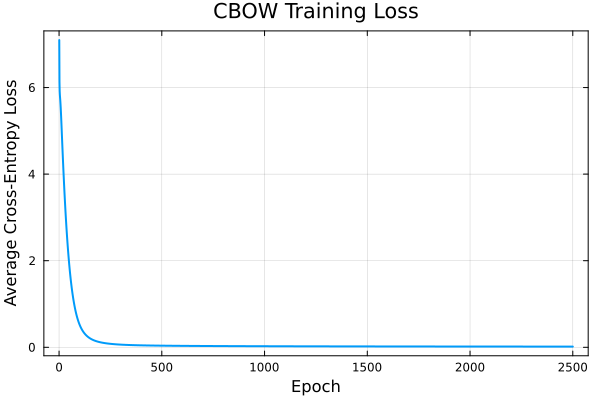

In [9]:
plot(loss_history;
    xlabel="Epoch", ylabel="Average Cross-Entropy Loss",
    title="CBOW Training Loss", legend=false, lw=2, framestyle=:box)

### Things to think about
* __Question:__ Look at the loss curve. Does it flatten out by the end of training, or is it still decreasing? If the loss were still dropping at epoch 2500, what is the simplest change you would make: increase the number of epochs, increase the learning rate, or increase the embedding dimension?
* __Question:__ Words `acid` and `base` appear in similar sentence structures in the corpus (e.g., "an acid donates..." / "a base accepts..."). After training, would you expect `acid` and `base` to have similar or different embedding vectors? Why?

___

## Task 2: Explore the Embedding Geometry

Before testing analogies, we visualize the learned embedding space. We use Principal Component Analysis (PCA) via SVD to project the $d_h$-dimensional embeddings to two dimensions and scatter-plot the words colored by semantic category. 

The CBOW model produces a $d_h$-dimensional embedding vector $\mathbf{e}_w \in \mathbb{R}^{d_h}$ for each vocabulary word $w$. With $d_h = 30$, we cannot directly plot these vectors. Principal Component Analysis (PCA) reduces the embedding matrix to two dimensions so we can visualize which words cluster together in the learned space. Let's first review principal component analysis:
> __PCA via the Singular Value Decomposition (SVD):__
>
> Let $\mathbf{E} \in \mathbb{R}^{d_h \times n}$ be the matrix whose $n$ columns are the embedding vectors of the words we want to visualize. We center the matrix by subtracting the mean embedding $\bar{\mathbf{e}} = \frac{1}{n}\sum_{i=1}^{n}\mathbf{e}_i$:
>
> $$\tilde{\mathbf{E}} = \mathbf{E} - \bar{\mathbf{e}}\mathbf{1}^{\top}$$
>
> We then decompose $\tilde{\mathbf{E}}$ using the Singular Value Decomposition $\tilde{\mathbf{E}} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\top}$, where the columns of $\mathbf{U} \in \mathbb{R}^{d_h \times d_h}$ are the principal directions in embedding space. The first two columns $\mathbf{U}_{:,1:2}$ span the 2D subspace that captures the most variance. The 2D coordinate matrix $\mathbf{C} \in \mathbb{R}^{n \times 2}$ is:
>
> $$\mathbf{C} = \left(\mathbf{U}_{:,1:2}^{\top}\,\tilde{\mathbf{E}}\right)^{\top}$$
>
> Row $i$ of $\mathbf{C}$ is the 2D coordinate of word $i$. Words that appear in similar contexts during training will have similar embeddings and will cluster together in this projection.

This SVD-based projection is equivalent to the covariance matrix eigendecomposition approach covered in L2d — the left singular vectors of the centered data matrix are the eigenvectors of its empirical covariance matrix.

> __What is going on in this code block?__
>
> We center the embedding matrix by subtracting its column mean [using the `mean(...)` function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.mean) and compute its singular value decomposition [using the `svd(...)` function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.svd). The first two columns of the left singular matrix `U` define the 2D projection. Words are colored by semantic category and labeled in the scatter plot.

Let's visualize the embedding space:

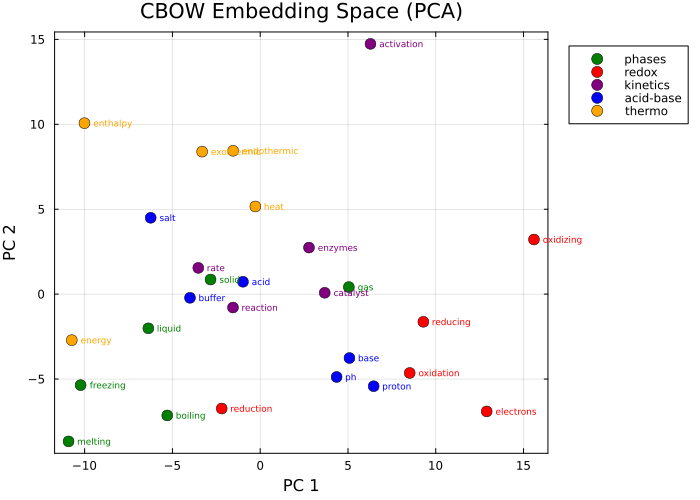

In [10]:
let
    category_words = Dict(
        "acid-base" => ["acid", "base", "proton", "ph", "salt", "buffer"],
        "redox"     => ["oxidation", "reduction", "electrons", "oxidizing", "reducing"],
        "thermo"    => ["exothermic", "endothermic", "heat", "enthalpy", "energy"],
        "phases"    => ["solid", "liquid", "gas", "melting", "boiling", "freezing"],
        "kinetics"  => ["catalyst", "reaction", "rate", "activation", "enzymes"],
    );
    category_colors = Dict(
        "acid-base" => :blue, "redox" => :red,
        "thermo" => :orange, "phases" => :green, "kinetics" => :purple,
    );

    words_plot, vecs, cats = String[], Vector{Float64}[], String[];
    for (cat, ws) in category_words
        for w in ws
            idx = get(vocabulary, w, 0);
            idx == 0 && continue;
            push!(words_plot, w);
            push!(vecs, W1[:, idx]);
            push!(cats, cat);
        end
    end

    E = hcat(vecs...);
    E_centered = E .- mean(E, dims=2);
    U, _, _ = svd(E_centered);
    coords = (U[:, 1:2]' * E_centered)';        # n × 2

    x_offset = 0.02 * (maximum(coords[:, 1]) - minimum(coords[:, 1]));

    p = plot(; title="CBOW Embedding Space (PCA)", xlabel="PC 1", ylabel="PC 2",
               legend=:outertopright, framestyle=:box, size=(700, 500));
    for cat in unique(cats)
        idxs = findall(cats .== cat);
        scatter!(p, coords[idxs, 1], coords[idxs, 2];
            label=cat, color=category_colors[cat], markersize=6, markerstrokewidth=0.5);
        for i in idxs
            annotate!(p, coords[i, 1] + x_offset, coords[i, 2],
                text(words_plot[i], 6, category_colors[cat], :left));
        end
    end
    p
end

> __What is going on in this code block?__
>
> We retrieve the top-3 nearest neighbors by cosine similarity for each query word [using the `nearest_neighbors(...)` function](src/CBOW.jl). If the embedding captures semantic proximity, the nearest neighbors of `acid` should include `base`, and the nearest neighbors of `exothermic` should include `endothermic`.

Let's inspect the nearest neighbors:

In [11]:
let
    # curated word list - same categories shown in the PCA figure -
    category_words = Dict(
        "acid-base" => ["acid", "base", "proton", "ph", "salt", "buffer"],
        "redox"     => ["oxidation", "reduction", "electrons"],
        "thermo"    => ["exothermic", "endothermic", "heat", "enthalpy", "energy", "releases", "absorbs"],
        "phases"    => ["solid", "liquid", "gas", "melting", "boiling", "freezing", "condensation"],
        "kinetics"  => ["catalyst", "reaction", "rate", "activation", "enzymes"],
    );

    # build sub-vocabulary restricted to curated words that exist in the full vocabulary -
    curated_words = vcat(values(category_words)...);
    sub_vocabulary = Dict{String,Int64}(w => vocabulary[w] for w in curated_words if haskey(vocabulary, w));

    # query words -
    query_words = ["acid", "oxidation", "exothermic", "solid", "catalyst"];
    queries   = String[];
    ranks     = Int[];
    neighbors = String[];
    sims      = Float64[];

    for qw in query_words
        nns = nearest_neighbors(W1, sub_vocabulary, qw; top_k=3);
        for (rank, (neighbor, sim)) in enumerate(nns)
            push!(queries,   qw);
            push!(ranks,     rank);
            push!(neighbors, neighbor);
            push!(sims,      sim);
        end
    end

    df_nn = DataFrame(
        "Query"            => queries,
        "Rank"             => ranks,
        "Neighbor"         => neighbors,
        "Cosine Similarity"=> sims,
    );
    pretty_table(df_nn, 
        backend = :text,
        fit_table_in_display_horizontally = false,
        table_format = TextTableFormat(borders = text_table_borders__compact)
    );
end

 ------------ ------- ------------- -------------------
       Query    Rank      Neighbor   Cosine Similarity 
      String   Int64        String             Float64 
 ------------ ------- ------------- -------------------
        acid       1     electrons              0.4307
        acid       2   endothermic              0.3846
        acid       3        energy              0.3769
   oxidation       1     electrons              0.4642
   oxidation       2        proton              0.4115
   oxidation       3      catalyst              0.3809
  exothermic       1   endothermic               0.715
  exothermic       2          salt              0.4453
  exothermic       3          rate              0.3561
       solid       1           gas              0.6299
       solid       2          acid              0.3669
       solid       3        liquid              0.3643
    catalyst       1            ph              0.4284
    catalyst       2      reaction              0.3885
    ca

### Things to think about
* __Question:__ Look at the nearest-neighbor table. The nearest neighbor of `acid` is `rate`, not `base`. What does this tell you about whether `acid` and `base` always appear within the same context window in the corpus?
* __Question:__ In the PCA scatter plot, do words from the same color (category) appear near each other? Pick two categories that overlap and suggest why their words might share similar contexts in a chemistry corpus.

___

## Task 3: Solve Word Analogies via Vector Arithmetic

The central demonstration of this lab: given that $a$ is to $b$ as $c$ is to $?$, we compute the target vector $\mathbf{v}_b - \mathbf{v}_a + \mathbf{v}_c$ and retrieve the closest word in the vocabulary by cosine similarity. We test several chemistry analogies that the parallel sentence structure in the corpus should support.

> __Analogy formula (vector offset method):__
>
> Let $\mathbf{v}_w = \mathbf{W}_1[:, \operatorname{idx}(w)]$ denote the embedding of word $w$. For the analogy $a : b :: c : ?$, the predicted answer is:
>
> $$d^* = \underset{d \in \mathcal{V} \setminus \{a,b,c\}}{\operatorname{argmax}} \;\cos\!\bigl(\mathbf{v}_d,\; \mathbf{v}_b - \mathbf{v}_a + \mathbf{v}_c\bigr)$$
>
> The notation $d \in \mathcal{V} \setminus \{a,b,c\}$ means that the search is over all words $d$ in the vocabulary $\mathcal{V}$ *except* the three input words $a$, $b$, and $c$. The backslash symbol $\setminus$ denotes set difference, so $\mathcal{V} \setminus \{a,b,c\}$ is the vocabulary with those three words removed. 
> 
> This exclusion prevents the model from trivially returning one of the input words as the answer. The function `solve_analogy(W1, vocabulary, a, b, c; top_k)` implements this lookup and returns the `top_k` candidates with their cosine similarity scores.

We test the following analogy sets [using the `solve_analogy(...)` function](src/CBOW.jl) derived from the corpus categories:

In [12]:
let
    # curated search vocabulary - same categories shown in the PCA figure -
    category_words = Dict(
        "acid-base" => ["acid", "base", "proton", "ph", "salt", "buffer"],
        "redox"     => ["oxidation", "reduction", "electrons"],
        "thermo"    => ["exothermic", "endothermic", "heat", "enthalpy", "energy", "releases", "absorbs"],
        "phases"    => ["solid", "liquid", "gas", "melting", "boiling", "freezing", "condensation"],
        "kinetics"  => ["catalyst", "reaction", "rate", "activation", "enzymes"],
    );
    curated_words = vcat(values(category_words)...);
    sub_vocabulary = Dict{String,Int64}(w => vocabulary[w] for w in curated_words if haskey(vocabulary, w));

    analogy_queries = [
        # (a, b, c, expected_d, display_string)
        ("acid",       "base",      "oxidation",   "reduction", "acid : base :: oxidation : ?"),
        ("oxidation",  "reduction", "acid",        "base",      "oxidation : reduction :: acid : ?"),
        ("exothermic", "releases",  "endothermic", "absorbs",   "exothermic : releases :: endothermic : ?"),
        ("melting",    "solid",     "boiling",     "liquid",    "melting : solid :: boiling : ?"),
        ("freezing",   "liquid",    "condensation","gas",       "freezing : liquid :: condensation : ?"),
        ("acid",       "proton",    "reduction",   "electrons", "acid : proton :: reduction : ?"),
    ];

    analogies  = String[];
    expected   = String[];
    rank1      = String[];  sim1 = Float64[];
    rank2      = String[];  sim2 = Float64[];
    rank3      = String[];  sim3 = Float64[];

    for (a, b, c, exp_word, desc) in analogy_queries
        results = solve_analogy(W1, sub_vocabulary, a, b, c; top_k=3);
        push!(analogies, desc);
        push!(expected,  exp_word);
        push!(rank1, length(results) >= 1 ? results[1][1] : "N/A"); push!(sim1, length(results) >= 1 ? results[1][2] : NaN);
        push!(rank2, length(results) >= 2 ? results[2][1] : "N/A"); push!(sim2, length(results) >= 2 ? results[2][2] : NaN);
        push!(rank3, length(results) >= 3 ? results[3][1] : "N/A"); push!(sim3, length(results) >= 3 ? results[3][2] : NaN);
    end

    df_analogy = DataFrame(
        "Analogy"    => analogies,
        "Expected"   => expected,
        "Rank 1"     => rank1,  "Sim 1" => sim1,
        "Rank 2"     => rank2,  "Sim 2" => sim2,
        "Rank 3"     => rank3,  "Sim 3" => sim3,
    );
    pretty_table(df_analogy, 
        backend = :text,
        fit_table_in_display_horizontally = false,
        table_format = TextTableFormat(borders = text_table_borders__compact)
    );
end

 ------------------------------------------ ----------- ----------- --------- ------------- --------- ------------- ---------
                                   Analogy    Expected      Rank 1     Sim 1        Rank 2     Sim 2        Rank 3     Sim 3 
                                    String      String      String   Float64        String   Float64        String   Float64 
 ------------------------------------------ ----------- ----------- --------- ------------- --------- ------------- ---------
              acid : base :: oxidation : ?   reduction          ph    0.3477        proton    0.3468      catalyst     0.327
         oxidation : reduction :: acid : ?        base      energy    0.4913    exothermic    0.4454          salt    0.3249
  exothermic : releases :: endothermic : ?     absorbs        base    0.1691         solid    0.1298     oxidation    0.1102
            melting : solid :: boiling : ?      liquid         gas    0.6519        proton    0.3444   endothermic    0.2

### Things to think about
* __Question:__ Which analogies return the expected word at rank 1? For the ones that fail, check whether the expected word appears at rank 2 or 3. What does it mean when the expected word is close but not the top result?
* __Question:__ The analogy `acid : proton :: reduction : ?` returns `electrons` correctly. Why might this analogy work when `acid : base :: oxidation : ?` does not? Hint: think about how directly each word pair co-occurs in the corpus sentences.

___

## Summary

This lab trained a CBOW model on a chemistry corpus and demonstrated that learned embeddings capture semantic relationships as linear structure in vector space.

> __Key Takeaways__
>
> * **CBOW learns embeddings from context co-occurrence:** Training on a domain corpus produces dense word vectors where semantically related words — those appearing in similar contexts — end up with high cosine similarity. The geometry of the embedding space reflects the co-occurrence structure of the training data.
> * **PCA visualization reveals semantic clusters:** Projecting the $d_h$-dimensional embeddings to two dimensions shows that words from the same chemical category tend to cluster together. This confirms that the model captures category membership from co-occurrence patterns alone.
> * **Word analogies exploit linear embedding structure:** The vector offset method recovers analogical relationships encoded in the corpus by treating semantic relationships as directions in embedding space. Analogy accuracy depends directly on how consistently the corpus places paired concepts in equivalent syntactic contexts.

Analogy performance on small corpora is limited by vocabulary coverage and training data size; scaling to larger domain text significantly improves the reliability of the vector offset method.

___